In [62]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np

# READING THE BLANK SCORE IMAGE AND THE NOTES IMAGE

blank = cv2.imread("dataset/train_data/empty_piano_score.png")

In [63]:
blank

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

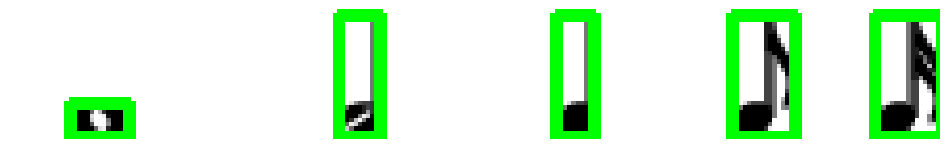

{288: 1.0, 345: 0.5, 330: 0.25, 564: 0.125, 666: 0.0625}
5


In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

raw = cv2.imread("dataset/train_data/all_piano_notes_duration.png")

# last_col = blank[:, -1:]
# extension = np.repeat(last_col, raw.shape[1] - blank.shape[1], axis=1)
# score_extended = np.concatenate([blank, extension], axis=1)

# raw = cv2.subtract(score_extended, raw)
# raw = cv2.bitwise_not(raw)

q = raw.copy()
q = cv2.erode(q, np.ones((2, 2)))

gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contours = [c for c in contours if cv2.contourArea(c) > 10]

# Sort largest first
contours = sorted(
    contours,
    key=lambda c: cv2.boundingRect(c)[2] * cv2.boundingRect(c)[3],
    reverse=True
)

kept = []
occupied = np.zeros(mask.shape, dtype=np.uint8)

for c in contours:
    contour_mask = np.zeros(mask.shape, dtype=np.uint8)
    cv2.drawContours(contour_mask, [c], -1, 255, thickness=cv2.FILLED)

    overlap = cv2.bitwise_and(occupied, contour_mask)

    # if even 1 pixel overlaps, skip it
    if cv2.countNonZero(overlap) == 0:
        kept.append(c)
        occupied = cv2.bitwise_or(occupied, contour_mask)

contours = kept

out = q.copy()
notes = []
px_counts_ns = []

i = 1
for c in contours:
    x, y, w, h = cv2.boundingRect(c)

    crop = q[y:y+h, x:x+w]
    notes.append(crop.copy())
    cv2.imwrite(f"dataset/train_data/note_{i}.png", crop)

    nonwhite = np.count_nonzero(crop != 255)
    px_counts_ns.append((x, nonwhite))
    px_counts_ns.sort()

    cv2.rectangle(out, (x, y), (x+w, y+h), (0, 255, 0), 2)
    i += 1

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

i = 0

px_counts = {}
for c in px_counts_ns:
    x, nw = c
    px_counts[nw] = 1 / 2 ** i
    i += 1
print(px_counts)
print(len(contours))

(29, 16, 3)


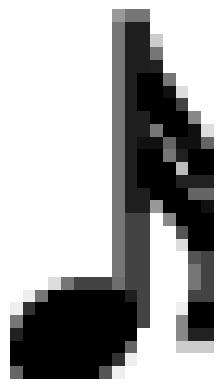

(29, 15, 3)


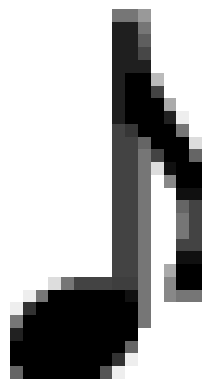

(29, 10, 3)


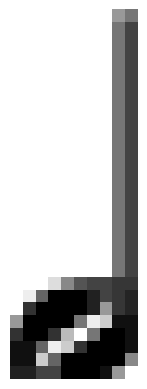

(29, 9, 3)


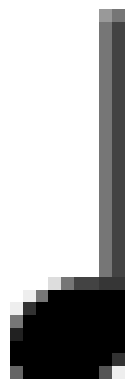

(8, 14, 3)


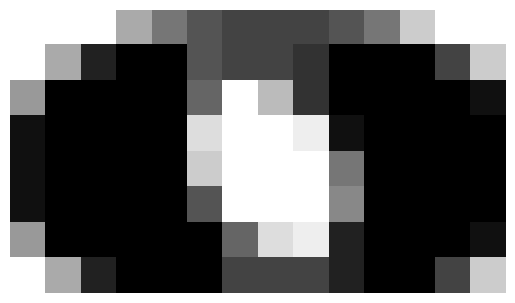

In [65]:
for note in notes:
    print(note.shape)
    plt.imshow(cv2.cvtColor(note, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [66]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torch
from PIL import Image

class NotesDataset(Dataset):
    def __init__(self, transform):
        super().__init__()

        self.transform = transform

    def __len__(self):
        return len(notes)
    
    def __getitem__(self, index):
        image = Image.open(f"dataset/train_data/note_{index+1}.png")
        label = torch.tensor(index + 1, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label
    
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = NotesDataset(transform)
loader = DataLoader(dataset, batch_size=5)

In [67]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1), # in 3, 64, 64
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 16 * 16, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
    )


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    total_loss = 0

    for images, labels in loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss = loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss: {total_loss:.4f}")

id_to_duration = {
    1: 1/16,
    2: 1/8,
    3: 1/2,
    4: 1/4,
    5: 1
}

Epoch 0, loss: 2.2692
Epoch 10, loss: 0.4474
Epoch 20, loss: 0.0200
Epoch 30, loss: 0.0005
Epoch 40, loss: 0.0001


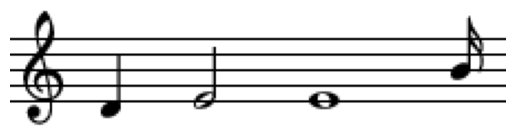

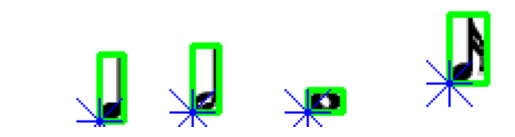

[(40, 'A'), (82, 'B'), (134, 'B'), (198, 'F')]

In [ ]:
# raw = cv2.imread("dataset/starter_kit/example.png")
raw = cv2.imread("dataset/test_data/0.png")
rawraw = raw.copy()

last_col = blank[:, -1:]
extension = np.repeat(last_col, raw.shape[1] - 143, axis=1)
score_extended = np.concatenate([blank, extension], axis=1)

raw = cv2.subtract(score_extended, raw)
raw = cv2.bitwise_not(raw)

q = raw.copy()
q = cv2.erode(q, np.ones((2, 2)))

kernel = np.ones((5, 5), np.uint8)
raw = cv2.erode(raw, kernel)
kernel = np.ones((3, 3), np.uint8)
raw = cv2.dilate(raw, kernel)

gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contours = [c for c in contours if cv2.contourArea(c) > 10]
out = q.copy()

detected = []

plt.imshow(cv2.cvtColor(rawraw, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

heights = []
height_to_tone = {50: 'A', 46: 'B', 42: 'C', 39: 'D', 35: 'E', 33: 'F', 28: 'G'}

i = 1
total = 0
model.eval()
with torch.no_grad():
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        crop = out[y:y+h, x:x+w]
        i += 1

        img_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img_rgb)
        image = transform(pil_img)   # Apply transforms
        image = image.unsqueeze(0)
        logits = model(image)
        pred = torch.argmax(logits, dim=1)
        pred = pred.item()

        nonwhite = np.count_nonzero(crop != 255)
        closest_key = min(px_counts, key=lambda k: abs(k - nonwhite))
        total += id_to_duration[pred]
        detected.append((x, height_to_tone[y+h], id_to_duration[pred]))

        cv2.rectangle(out, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.drawMarker(out, (x, y+h), (255, 0, 0), cv2.MARKER_STAR)

        heights.append(y+h)

plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# height_to_tone = {}

# i = 0
# for height in heights:
#     height_to_tone[height] = chr(ord('A') + i)
#     i += 1

sorted(detected)


In [ ]:
import glob
import os
from tqdm import tqdm
import pandas as pd

test_paths = sorted(glob.glob("dataset/test_data/*.png"))

results = []

for path in tqdm(test_paths):
    dp_id = int(os.path.basename(path).split('.')[0])
    raw = cv2.imread(path)

    last_col = blank[:, -1:]
    extension = np.repeat(last_col, raw.shape[1] - 143, axis=1)
    score_extended = np.concatenate([blank, extension], axis=1)

    raw = cv2.subtract(score_extended, raw)
    raw = cv2.bitwise_not(raw)

    q = raw.copy()
    q = cv2.erode(q, np.ones((2, 2)))

    kernel = np.ones((5, 5), np.uint8)
    raw = cv2.erode(raw, kernel)
    kernel = np.ones((3, 3), np.uint8)
    raw = cv2.dilate(raw, kernel)

    gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

    contours, hierarchy = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = [c for c in contours if cv2.contourArea(c) > 10]
    out = q.copy()

    detected = []

    i = 1
    total = 0
    model.eval()
    with torch.no_grad():
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)

            crop = out[y:y+h, x:x+w]
            closest_key = min(height_to_tone, key=lambda k: abs(k - y+h))
            detected.append((y+h, height_to_tone[closest_key]))
            i += 1

            img_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(img_rgb)
            image = transform(pil_img)   # Apply transforms
            image = image.unsqueeze(0)
            logits = model(image)
            pred = torch.argmax(logits, dim=1)
            pred = pred.item()

            total += id_to_duration[pred]

            cv2.rectangle(out, (x, y), (x+w, y+h), (0, 255, 0), 2)

    s = ''
    for note in sorted(detected):
        s += 


    # --------------- SUBTASK 1 ---------------
    # WRITE YOUR OWN CODE HERE
    ans_subtask1  = len(contours)

    # --------------- SUBTASK 2 ---------------
    # WRITE YOUR OWN CODE HERE
    ans_subtask2  = total

    # --------------- SUBTASK 3 ---------------
    # WRITE YOUR OWN CODE HERE
    ans_subtask3  = ""


    results.extend([[1, dp_id, ans_subtask1], [2, dp_id, ans_subtask2], [3, dp_id, ans_subtask3]])

    pd.DataFrame(results, columns=["subtaskID", "datapointID", "answer"]).to_csv("submission.csv", index=False)

100%|██████████| 2000/2000 [00:46<00:00, 43.42it/s]
